# Recurrent Neural Networks (RNN) — Theory & Implementation


## 1. The Problem — Why Can't Regular Neural Networks Handle Sequences?

In our previous lecture, we built a feedforward neural network (Dense layers) for classification. That network takes a **fixed-size input** (30 features), processes it through layers, and produces an output. Every input is treated **independently** — the model has no memory of what it saw before.

But many real-world problems involve **sequences** — data where the **order matters** and the **past influences the future**:

- **Language:** "The cat sat on the ___" — to predict the next word, you need context from the preceding words. If you just saw the word "the" in isolation, you could not predict what comes next.

- **Time series:** Tomorrow's stock price depends on today's, yesterday's, and last week's prices — not just a single snapshot.

- **Speech:** The sound of a phoneme depends on the sounds that came before it.

- **Music:** The next note depends on the melody so far.

- **Video:** Understanding a scene requires knowing what happened in previous frames.

### Why Dense Networks Fail at Sequences

A regular Dense (feedforward) network has three fundamental problems with sequential data:

1. **No memory** — Each input is processed independently. The network does not remember what it saw one step ago. If you feed it word by word, it treats each word as if it appeared in a vacuum.

2. **Fixed input size** — Dense networks require a fixed number of inputs. But sentences have variable lengths, songs have different durations, and time series can span different periods.

3. **No parameter sharing across time** — If a pattern (like "not" negating sentiment) appears at position 3 in one sentence and position 15 in another, a Dense network would need to learn this pattern separately for each position.

We need a network architecture that has **memory** — one that can process sequences step by step while maintaining an internal state that captures what it has seen so far. This is what **Recurrent Neural Networks (RNNs)** provide.

## 2. The RNN Architecture — A Network with Memory

### The Core Idea

An RNN processes a sequence **one element at a time** (one word, one time step, one frame). At each step, it does two things:

1. Takes the **current input** ($x_t$)
2. Takes the **previous hidden state** ($h_{t-1}$) — this is the "memory" from all previous steps

It combines these two and produces:
- A **new hidden state** ($h_t$) — the updated memory
- An **output** ($y_t$) — the prediction at this step (optional, depending on the task)

### The Math (Simplified)

At each time step $t$:

$$h_t = \tanh(W_{hh} \cdot h_{t-1} + W_{xh} \cdot x_t + b_h)$$

$$y_t = W_{hy} \cdot h_t + b_y$$

Where:
- $x_t$ = input at time step $t$
- $h_{t-1}$ = hidden state from the previous step (the memory)
- $h_t$ = new hidden state after processing $x_t$
- $W_{hh}$ = weight matrix for the hidden-to-hidden connection (how memory transforms)
- $W_{xh}$ = weight matrix for the input-to-hidden connection (how input is processed)
- $W_{hy}$ = weight matrix for the hidden-to-output connection
- $\tanh$ = activation function (squashes values to [-1, 1])

### The Key Insight — Parameter Sharing

The **same weights** ($W_{hh}$, $W_{xh}$, $W_{hy}$) are used at **every time step**. The network learns one set of rules and applies them repeatedly across the sequence. This is fundamentally different from a Dense network, which has separate parameters for each input position.

This parameter sharing means:
- The model can handle **variable-length sequences** (just run more or fewer steps)
- Patterns learned at one position **generalize to all positions**
- The model is **much more parameter-efficient** than a Dense network on sequences

### The Hidden State — The Memory

The hidden state $h_t$ is the RNN's memory. It is a vector that summarizes **everything the network has seen so far** in the sequence. As the RNN processes each element:

- $h_0$: initialized to zeros (no memory yet)
- $h_1$: encodes information from $x_1$
- $h_2$: encodes information from $x_1$ and $x_2$
- $h_T$: encodes information from the **entire sequence**

The final hidden state $h_T$ is often used as a fixed-size representation of the whole sequence — this is how an RNN converts a variable-length sequence into a fixed-size vector for classification or regression.

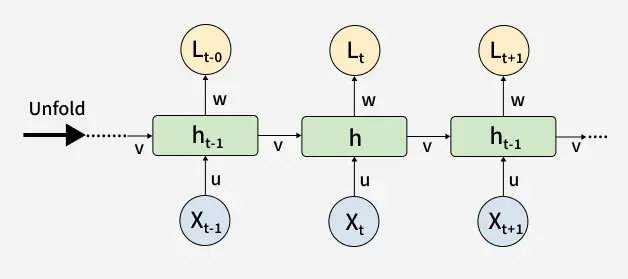

## 3. Types of RNN Architectures

Depending on the task, we use different input-output patterns:

### One-to-Many
Single input → sequence output. Example: image captioning (one image → sequence of words).

### Many-to-One
Sequence input → single output. Example: sentiment analysis (sequence of words → positive/negative). The RNN processes the entire sequence and uses the **final hidden state** to make one prediction.

### Many-to-Many (Equal Length)
Sequence input → sequence output (same length). Example: part-of-speech tagging (each word gets a label).

### Many-to-Many (Different Length)
Sequence input → sequence output (different length). Example: machine translation (English sentence → French sentence). Uses an **encoder-decoder** architecture.

In today's implementation, we will focus on **many-to-one** (time-series forecasting: sequence of past values → predict next value).

## 4. The Vanishing Gradient Problem — Why Vanilla RNNs Struggle

In theory, an RNN can learn dependencies across the entire sequence — $h_T$ encodes information from $x_1$ all the way to $x_T$. In practice, **vanilla RNNs cannot learn long-range dependencies**.

### Why?

During backpropagation through time (BPTT), gradients are multiplied by the weight matrix $W_{hh}$ at **every time step**. If $W_{hh}$ has values < 1, the gradients **shrink exponentially** as they flow backward through many steps. After 20-30 steps, the gradient is essentially zero — the network cannot learn that early inputs matter.

This is the **vanishing gradient problem**:
- The RNN "forgets" early parts of the sequence
- It can only learn short-range patterns (5-10 steps)
- Long sentences, long time series, and long melodies are beyond its reach

The reverse can also happen — if $W_{hh}$ has values > 1, gradients **explode** (growing to infinity), making training unstable. This is the **exploding gradient problem** (partially solved by gradient clipping).

### Analogy

Imagine playing the telephone game with 50 people. The message at the start gets distorted with each passing — by the end, it bears no resemblance to the original. The vanilla RNN has the same problem: information from early time steps gets "diluted" as it passes through many hidden state transformations.

This fundamental limitation led to the invention of **LSTM** and **GRU** — architectures specifically designed to solve the vanishing gradient problem.

## 5. LSTM — Long Short-Term Memory

LSTM (Hochreiter & Schmidhuber, 1997) is the most important advancement in RNN history. It solves the vanishing gradient problem by introducing a sophisticated **gating mechanism** that controls what information to remember, what to forget, and what to output.

### The Key Innovation — The Cell State

In addition to the hidden state $h_t$, LSTM introduces a **cell state** $C_t$ — think of it as a conveyor belt that runs through the entire sequence. Information can be added to or removed from the cell state through gates, but by default, information flows unchanged. This creates a **highway** for gradients to flow backward without vanishing.

### The Three Gates

LSTM has three gates — each is a neural network layer with a sigmoid activation (outputs 0-1, where 0 = "block everything" and 1 = "let everything through"):

**1. Forget Gate ($f_t$):** "What should I forget from the cell state?"

$$f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)$$

Looks at the previous hidden state and current input, and outputs a value between 0 and 1 for each element of the cell state. 0 means "completely forget this" and 1 means "completely keep this."

Example: When processing language and encountering a new subject, the forget gate might discard the old subject's gender information.

**2. Input Gate ($i_t$) + Candidate Values ($\tilde{C}_t$):** "What new information should I store?"

$$i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)$$
$$\tilde{C}_t = \tanh(W_C \cdot [h_{t-1}, x_t] + b_C)$$

The input gate decides which values to update, and the tanh layer creates candidate values to add.

**3. Output Gate ($o_t$):** "What should I output from the cell state?"

$$o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)$$
$$h_t = o_t \odot \tanh(C_t)$$

Decides which parts of the cell state to expose as the hidden state output.

### Cell State Update

$$C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$$

The old cell state is multiplied by the forget gate (discarding what we chose to forget), then we add the new candidate values scaled by the input gate.

### Why LSTM Works

The cell state acts as a highway — gradients can flow backward through it without being multiplied by weight matrices at every step. The forget gate can be close to 1 ("remember everything"), allowing information from 100+ steps ago to survive. This solves the vanishing gradient problem.

## 6. GRU — Gated Recurrent Unit

GRU (Cho et al., 2014) is a simplified version of LSTM with **two gates** instead of three:

1. **Reset Gate ($r_t$):** How much of the past to forget
2. **Update Gate ($z_t$):** How much of the new state vs old state to keep (combines LSTM's forget and input gates)

### GRU vs LSTM

| Aspect | LSTM | GRU |
|--------|------|-----|
| Gates | 3 (forget, input, output) | 2 (reset, update) |
| States | Hidden state + Cell state | Hidden state only |
| Parameters | More (~4x vanilla RNN) | Fewer (~3x vanilla RNN) |
| Training speed | Slower | Faster |
| Performance | Often slightly better on long sequences | Comparable for most tasks |
| When to use | Long sequences, complex dependencies | Shorter sequences, faster training |

**Rule of thumb:** Start with LSTM. If training is too slow or the sequences are short, try GRU. Performance is often very similar.

## 7. Preparing Sequential Data — Windowing

Before we can feed data to an RNN, we need to transform it into sequences. For time-series forecasting, we use a **sliding window** approach:

Given a series: `[10, 20, 30, 40, 50, 60, 70]`

With a window size of 3:

| Input Sequence (X) | Target (y) |
|--------------------|------------|
| [10, 20, 30] | 40 |
| [20, 30, 40] | 50 |
| [30, 40, 50] | 60 |
| [40, 50, 60] | 70 |

The RNN learns: "Given these past N values, predict the next one."

### Input Shape for Keras RNNs

Keras RNN layers expect input shape: **(batch_size, time_steps, features)**

- **batch_size:** Number of sequences in a batch (handled automatically)
- **time_steps:** Length of each sequence (our window size)
- **features:** Number of variables at each time step (1 for univariate, more for multivariate)

This 3D shape is crucial — forgetting to reshape is the most common RNN error.


# IMPLEMENTATION

## 8. Setup and Imports

**Task:** Import TensorFlow, Keras layers, and standard libraries.

In [1]:
# Import tensorflow as tf
# Import numpy as np
# Import pandas as pd
# Import matplotlib.pyplot as plt

# From tensorflow.keras.models import Sequential
# From tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense, Dropout
# From tensorflow.keras.callbacks import EarlyStopping

# From sklearn.preprocessing import MinMaxScaler
# From sklearn.metrics import mean_squared_error, mean_absolute_error

# Set seeds for reproducibility
# np.random.seed(42)
# tf.random.set_seed(42)

# Print TF version



import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")


I0000 00:00:1775026269.712848   28083 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775026270.189281   28083 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775026274.270047   28083 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow version: 2.21.0
GPU: []


E0000 00:00:1775026277.511774   28083 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1775026277.564320   28083 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


---

## 9. Creating a Synthetic Time Series

We will generate a synthetic time series with a known pattern — a sine wave with trend and noise. Since we know the true pattern, we can evaluate how well the RNN learns it.

**Task:** Generate a sine wave time series with trend and noise.

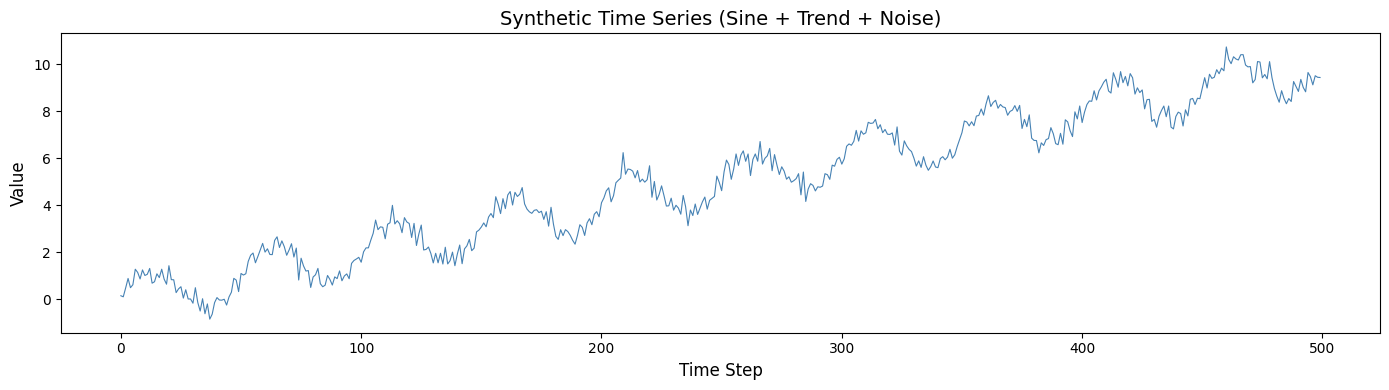

Series length: 500
Value range: [-0.85, 10.74]
Components: sin(period=50) + trend(0.02*t) + noise(std=0.3)


In [2]:
# Create a time axis: t = np.arange(0, 500)

# Generate the series:
# signal = sine wave (period ~50) + linear trend (0.02*t) + random noise (std=0.3)
# series = np.sin(2 * np.pi * t / 50) + 0.02 * t + np.random.normal(0, 0.3, len(t))

# Plot the full series with figsize=(14, 4)
# Title: 'Synthetic Time Series (Sine + Trend + Noise)'
# Show the plot

# Print the series length and value range


t = np.arange(0, 500)
series = np.sin(2 * np.pi * t / 50) + 0.02 * t + np.random.normal(0, 0.3, len(t))

plt.figure(figsize=(14, 4))
plt.plot(t, series, linewidth=0.8, color='steelblue')
plt.title('Synthetic Time Series (Sine + Trend + Noise)', fontsize=14)
plt.xlabel('Time Step', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.tight_layout()
plt.show()

print(f"Series length: {len(series)}")
print(f"Value range: [{series.min():.2f}, {series.max():.2f}]")
print(f"Components: sin(period=50) + trend(0.02*t) + noise(std=0.3)")


**What to observe:** The series has three components we discussed in the Time-Series Theory lecture: a **trend** (upward slope), **seasonality** (the sine wave oscillation), and **noise** (random fluctuations). The RNN's job is to learn the trend and seasonality while ignoring the noise.

---

## 10. Data Preprocessing for RNN

### 10.1 Scaling

Neural networks work best with values between 0 and 1 (or -1 and 1). For time series, **MinMaxScaler** is commonly used instead of StandardScaler because it preserves the shape of the distribution.

**Important:** Fit the scaler on training data only, then transform both train and test.

### 10.2 Train/Test Split

**Never shuffle time-series data!** We split chronologically — the first 80% for training, the last 20% for testing.

### 10.3 Creating Sequences (Windowing)

We transform the flat series into input-output pairs using sliding windows.

**Task:** Scale the data, split chronologically, and create sequences.

In [3]:
# # Reshape series for scaler: series.reshape(-1, 1)

# # Create MinMaxScaler(feature_range=(0, 1))

# # Split: first 80% = train, last 20% = test
# # train_size = int(len(series) * 0.8)

# # Fit scaler on training portion only, then transform both

# # Print train and test sizes

# # Scale
scaler = MinMaxScaler(feature_range=(0, 1))
series_reshaped = series.reshape(-1, 1)

train_size = int(len(series) * 0.8)
train_raw = series_reshaped[:train_size]
test_raw = series_reshaped[train_size:]

train_scaled = scaler.fit_transform(train_raw)
test_scaled = scaler.transform(test_raw)

print(f"Training set: {len(train_scaled)} steps")
print(f"Test set:     {len(test_scaled)} steps")
print(f"Scale range after transform: [{train_scaled.min():.3f}, {train_scaled.max():.3f}]")


Training set: 400 steps
Test set:     100 steps
Scale range after transform: [0.000, 1.000]


In [4]:
# Define a function to create sequences:
# def create_sequences(data, window_size):
#     X, y = [], []
#     for i in range(len(data) - window_size):
#         X.append(data[i : i + window_size])
#         y.append(data[i + window_size])
#     return np.array(X), np.array(y)

# Set WINDOW_SIZE = 30 (use past 30 steps to predict the next)

# Create sequences for train and test

# Print shapes: X_train should be (samples, 30, 1), y_train should be (samples,)

def create_sequences(data, window_size):
    """Create input-output pairs using sliding window."""
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i : i + window_size])
        y.append(data[i + window_size])
    return np.array(X), np.array(y).flatten()

WINDOW_SIZE = 30

X_train, y_train = create_sequences(train_scaled, WINDOW_SIZE)
X_test, y_test = create_sequences(test_scaled, WINDOW_SIZE)

print(f"Window size: {WINDOW_SIZE}")
print(f"X_train shape: {X_train.shape} — (samples, time_steps, features)")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_test shape:  {y_test.shape}")


Window size: 30
X_train shape: (370, 30, 1) — (samples, time_steps, features)
y_train shape: (370,)
X_test shape:  (70, 30, 1)
y_test shape:  (70,)


**What to observe:** The X shape should be 3D: `(num_samples, window_size, 1)`. The `1` at the end is the number of features (univariate — just one variable). If we had multiple features (e.g., temperature + humidity), this last dimension would be larger. The y shape is 1D: `(num_samples,)` — one target value per sequence.

---

## 11. Building a Simple (Vanilla) RNN

Let us start with the simplest RNN — `SimpleRNN` in Keras. This is the vanilla RNN from our theory discussion. We expect it to work on our relatively short sequences (window=30) but struggle with longer dependencies.

**Task:** Build, compile, and train a SimpleRNN model.

In [5]:
# Build the model:
# model_rnn = Sequential([
#     SimpleRNN(50, activation='tanh', input_shape=(WINDOW_SIZE, 1)),
#     Dense(1)
# ])

# Compile: optimizer='adam', loss='mse'

# Print model summary

model_rnn = Sequential([
    SimpleRNN(50, activation='tanh', input_shape=(WINDOW_SIZE, 1)),
    Dense(1)
])

model_rnn.compile(optimizer='adam', loss='mse')
model_rnn.summary()

print(f"\nParameter breakdown:")
print(f"  SimpleRNN: (50*1) + (50*50) + 50 = {50*1 + 50*50 + 50}")
print(f"  Dense:     (50*1) + 1 = {50*1 + 1}")


/home/fm-pc-lt-269/anaconda3/envs/datascience/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)


Parameter breakdown:
  SimpleRNN: (50*1) + (50*50) + 50 = 2600
  Dense:     (50*1) + 1 = 51


In [6]:
# Train:
# history_rnn = model_rnn.fit(
#     X_train, y_train,
#     epochs=50,
#     batch_size=32,
#     validation_split=0.1,
#     verbose=1
# )

t0 = time.time()
history_rnn = model_rnn.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=0
)
rnn_time = time.time() - t0

print(f"SimpleRNN training: {rnn_time:.1f}s")
print(f"  Final train loss: {history_rnn.history['loss'][-1]:.6f}")
print(f"  Final val loss:   {history_rnn.history['val_loss'][-1]:.6f}")


SimpleRNN training: 6.3s
  Final train loss: 0.001252
  Final val loss:   0.001672


**What to observe:** Note the parameter count in the summary. SimpleRNN(50) with input features=1 has: (50 × 1) + (50 × 50) + 50 = 2,600 parameters. The `50 × 50` term is the hidden-to-hidden weight matrix $W_{hh}$ — this is what gives the RNN its memory.

---

## 12. Building an LSTM Model

Now let us build the same task with LSTM — the architecture designed to handle long-range dependencies. Keras makes switching from SimpleRNN to LSTM trivial — just change the layer name.

**Task:** Build, compile, and train an LSTM model.

In [7]:
# Build:
# model_lstm = Sequential([
#     LSTM(50, activation='tanh', input_shape=(WINDOW_SIZE, 1)),
#     Dense(1)
# ])

# Compile: optimizer='adam', loss='mse'

# Print summary — compare parameter count with SimpleRNN

model_lstm = Sequential([
    LSTM(50, activation='tanh', input_shape=(WINDOW_SIZE, 1)),
    Dense(1)
])

model_lstm.compile(optimizer='adam', loss='mse')
model_lstm.summary()

print(f"\nParameter breakdown:")
print(f"  LSTM: 4 × [(50×1) + (50×50) + 50] = {4*(50*1 + 50*50 + 50)}")
print(f"  Dense: (50×1) + 1 = {50+1}")
print(f"  LSTM has ~4× the parameters of SimpleRNN!")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)


Parameter breakdown:
  LSTM: 4 × [(50×1) + (50×50) + 50] = 10400
  Dense: (50×1) + 1 = 51
  LSTM has ~4× the parameters of SimpleRNN!


In [8]:
# Train:
# history_lstm = model_lstm.fit(
#     X_train, y_train,
#     epochs=50,
#     batch_size=32,
#     validation_split=0.1,
#     verbose=1
# )
t0 = time.time()
history_lstm = model_lstm.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=0
)
lstm_time = time.time() - t0

print(f"LSTM training: {lstm_time:.1f}s")
print(f"  Final train loss: {history_lstm.history['loss'][-1]:.6f}")
print(f"  Final val loss:   {history_lstm.history['val_loss'][-1]:.6f}")

LSTM training: 8.8s
  Final train loss: 0.001212
  Final val loss:   0.001759


**What to observe:** LSTM has **~4x more parameters** than SimpleRNN with the same number of units. This is because LSTM has 4 internal weight matrices (for the 3 gates + candidate values) versus SimpleRNN's 1. More parameters = more capacity to learn complex patterns, but slower training.

---

## 13. Building a GRU Model

For completeness, let us also build a GRU model — the lighter alternative to LSTM.

**Task:** Build, compile, and train a GRU model.

In [9]:
model_gru = Sequential([
    GRU(50, activation='tanh', input_shape=(WINDOW_SIZE, 1)),
    Dense(1)
])

model_gru.compile(optimizer='adam', loss='mse')
model_gru.summary()

print(f"\nParameter comparison:")
print(f"  SimpleRNN(50): {50*1 + 50*50 + 50:>6} params  (1×)")
print(f"  GRU(50):       {3*(50*1 + 50*50 + 50):>6} params  (3×)")
print(f"  LSTM(50):      {4*(50*1 + 50*50 + 50):>6} params  (4×)")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 50)             │         7,950 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,001 (31.25 KB)

 Trainable params: 8,001 (31.25 KB)

 Non-trainable params: 0 (0.00 B)


Parameter comparison:
  SimpleRNN(50):   2600 params  (1×)
  GRU(50):         7800 params  (3×)
  LSTM(50):       10400 params  (4×)


In [10]:
# Train:
# history_gru = model_gru.fit(
#     X_train, y_train,
#     epochs=50,
#     batch_size=32,
#     validation_split=0.1,
#     verbose=1
# )

t0 = time.time()
history_gru = model_gru.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=0
)
gru_time = time.time() - t0

print(f"GRU training: {gru_time:.1f}s")
print(f"  Final train loss: {history_gru.history['loss'][-1]:.6f}")
print(f"  Final val loss:   {history_gru.history['val_loss'][-1]:.6f}")


GRU training: 9.0s
  Final train loss: 0.001578
  Final val loss:   0.001855


**What to observe:** GRU has **~3x** the parameters of SimpleRNN (2 gates + candidate, vs LSTM's 3 gates + candidate). It sits between SimpleRNN and LSTM in complexity.

---

## 14. Comparing Training Curves

**Task:** Plot the training loss curves for all three models side by side.

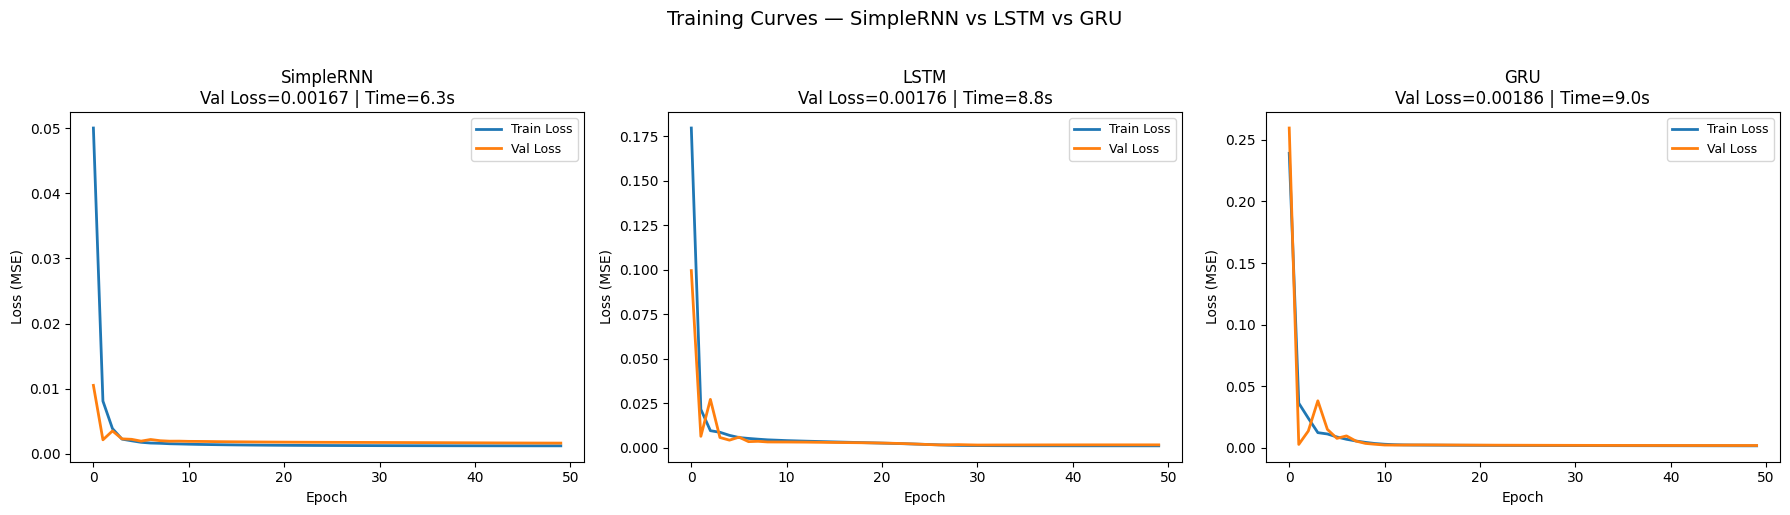

In [11]:
# Create a figure with 1 row, 3 columns, figsize=(18, 5)

# For each model (SimpleRNN, LSTM, GRU):
#   Plot training loss and validation loss
#   Add title with model name and final val loss

# plt.tight_layout() and plt.show()


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_hist = [
    ('SimpleRNN', history_rnn, rnn_time),
    ('LSTM', history_lstm, lstm_time),
    ('GRU', history_gru, gru_time)
]

for i, (name, hist, ttime) in enumerate(models_hist):
    axes[i].plot(hist.history['loss'], label='Train Loss', linewidth=2)
    axes[i].plot(hist.history['val_loss'], label='Val Loss', linewidth=2)
    final_val = hist.history['val_loss'][-1]
    axes[i].set_title(f'{name}\nVal Loss={final_val:.5f} | Time={ttime:.1f}s', fontsize=12)
    axes[i].set_xlabel('Epoch')
    axes[i].set_ylabel('Loss (MSE)')
    axes[i].legend(fontsize=9)

plt.suptitle('Training Curves — SimpleRNN vs LSTM vs GRU', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


**What to observe:** LSTM and GRU typically achieve lower validation loss than SimpleRNN — they learn the patterns more effectively. LSTM and GRU usually converge similarly, with GRU sometimes training slightly faster.

---

## 15. Making Predictions and Evaluating

Now let us use the trained models to predict on the test set and visualize how well they track the actual values.

**Task:** Generate predictions from all three models and compute error metrics.

In [12]:
# For each model:
#   Predict on X_test
#   Inverse transform predictions and y_test back to original scale
#   Compute RMSE and MAE

# Display comparison table: Model, RMSE, MAE

def evaluate_model(model, model_name, X_test, y_test, scaler):
    """Predict, inverse-transform, compute metrics."""
    y_pred_scaled = model.predict(X_test, verbose=0).flatten()
    y_pred = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
    y_actual = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

    rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
    mae = mean_absolute_error(y_actual, y_pred)
    return y_pred, y_actual, rmse, mae

results = []
predictions = {}

for name, model, ttime in [('SimpleRNN', model_rnn, rnn_time),
                             ('LSTM', model_lstm, lstm_time),
                             ('GRU', model_gru, gru_time)]:
    y_pred, y_actual, rmse, mae = evaluate_model(model, name, X_test, y_test, scaler)
    predictions[name] = y_pred
    results.append({
        'Model': name,
        'RMSE': round(rmse, 4),
        'MAE': round(mae, 4),
        'Train Time (s)': round(ttime, 1)
    })

results_df = pd.DataFrame(results)
print("=" * 55)
print("  MODEL COMPARISON — Time Series Forecasting")
print("=" * 55)
print(results_df.to_string(index=False))
print("=" * 55)


  MODEL COMPARISON — Time Series Forecasting
    Model   RMSE    MAE  Train Time (s)
SimpleRNN 0.4298 0.3501             6.3
     LSTM 0.4297 0.3559             8.8
      GRU 0.4197 0.3257             9.0


### 15.1 Visualizing Predictions vs Actuals

**Task:** Plot the predicted values against the actual test values for the best model.

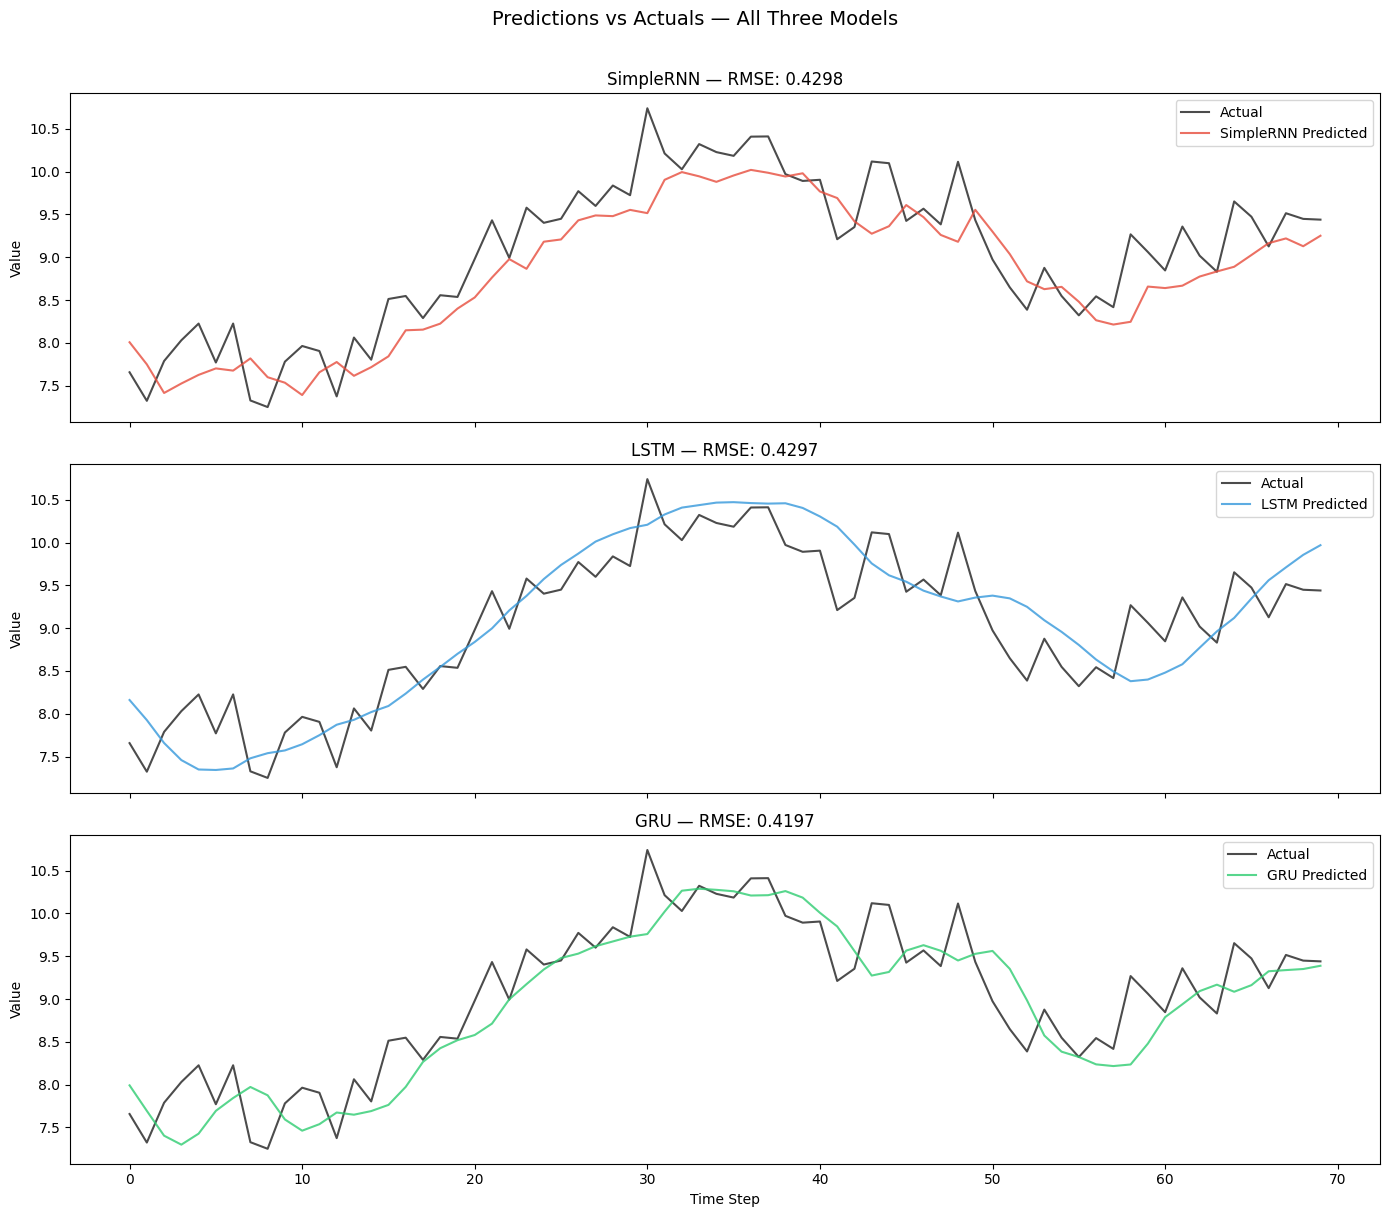

In [13]:
# Create a figure with figsize=(14, 5)

# Plot actual test values as a line
# Plot LSTM predictions as a line (different color)

# Title: 'LSTM Predictions vs Actual Values'
# Add legend, labels
# Show the plot

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

for i, (name, color) in enumerate([('SimpleRNN', '#e74c3c'),
                                      ('LSTM', '#3498db'),
                                      ('GRU', '#2ecc71')]):
    axes[i].plot(y_actual, label='Actual', linewidth=1.5, color='black', alpha=0.7)
    axes[i].plot(predictions[name], label=f'{name} Predicted', linewidth=1.5,
                  color=color, alpha=0.8)
    axes[i].set_title(f'{name} — RMSE: {results_df[results_df.Model==name]["RMSE"].values[0]}',
                       fontsize=12)
    axes[i].legend(fontsize=10)
    axes[i].set_ylabel('Value')

axes[2].set_xlabel('Time Step')
plt.suptitle('Predictions vs Actuals — All Three Models', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


---

## 18. Practical Tips for RNN Projects

1. **Always scale your data** — MinMaxScaler(0,1) or StandardScaler. NNs are sensitive to scale.

2. **Choose window size carefully** — Too small: not enough context. Too large: harder to train, may include irrelevant history. Experiment with multiple sizes.

3. **Start with LSTM** — It is the default choice. Try GRU if training is slow. Avoid vanilla RNN for anything beyond toy problems.

4. **Use Dropout** (0.2-0.3) between LSTM layers to prevent overfitting.

5. **Use Early Stopping** — Monitor validation loss and stop when it plateaus.

6. **Reshape your data to 3D** — `(samples, time_steps, features)`. This is the most common source of errors.

7. **Inverse-transform predictions** before computing error metrics — you want errors in the original scale, not the scaled scale.

8. **Consider bidirectional LSTMs** — Process the sequence both forward and backward. Useful for NLP tasks where future context also matters.

9. **For tabular time-series**, also try classical approaches (ARIMA, Prophet) and ML approaches (XGBoost with lag features). RNNs are not always the best choice.

---

## 19. Summary and Key Takeaways

**Why RNNs:**
- Sequential data needs models with **memory**
- Dense networks have no memory, fixed input size, no parameter sharing across time
- RNNs process sequences step by step, maintaining a hidden state

**RNN Variants:**

| Model | Gates | Strength | Weakness |
|-------|-------|----------|----------|
| SimpleRNN | None | Simple, fast | Vanishing gradients, short memory |
| LSTM | 3 (forget, input, output) | Long-range memory, robust | More parameters, slower |
| GRU | 2 (reset, update) | Simpler than LSTM, fast | Slightly less capacity |

**Key Concepts:**
- **Hidden state** = the RNN's memory, updated at each step
- **Cell state** (LSTM) = information highway that solves vanishing gradients
- **Gating** = learned mechanisms to forget, remember, and output selectively
- **Windowing** = transform flat series into (X_sequence, y_target) pairs
- **3D input shape** = (samples, time_steps, features)

**Keras RNN Layers:**
- `SimpleRNN(units)` — Vanilla RNN
- `LSTM(units)` — Long Short-Term Memory
- `GRU(units)` — Gated Recurrent Unit
- `return_sequences=True` — Output at every time step (needed for stacking)

**What comes next:** CNNs for image data, Transformer architecture, and advanced NLP.